# Split Ratio Planner
Provide split ratios, get `validation_start`, `test_start`, `anomaly_start_time` and a plot.

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data inputs (same style as YAML)
data_file = "data/exp01_data/ts_weekly_values.csv"
datetime_file = "data/exp01_data/ts_weekly_datetimes.csv"
datetime_column = "LGA008EFAPRG910_cleaned"
value_column = "LGA008EFAPRG910_cleaned"

# Ratios
train_ratio = 0.50
validation_ratio = 0.10
test_ratio = 0.40

# Where anomaly starts within test split (0=start of test, 1=end of test)
anomaly_ratio_in_test = 0.30

In [20]:
def resolve_project_path(path_like: str) -> Path:
    p = Path(path_like)
    if p.is_absolute() and p.exists():
        return p
    c1 = (Path.cwd() / p).resolve()
    if c1.exists():
        return c1
    root = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
    c2 = (root / p).resolve()
    if c2.exists():
        return c2
    return c1

def load_series(data_file, datetime_file, datetime_column, value_column):
    v_path = resolve_project_path(data_file)
    t_path = resolve_project_path(datetime_file)
    if not v_path.exists():
        raise FileNotFoundError(f"data_file not found: {data_file} | tried: {v_path}")
    if not t_path.exists():
        raise FileNotFoundError(f"datetime_file not found: {datetime_file} | tried: {t_path}")

    df_v = pd.read_csv(v_path)
    df_t = pd.read_csv(t_path)
    if value_column not in df_v.columns:
        raise KeyError(f"value_column '{value_column}' not in {v_path}")
    if datetime_column not in df_t.columns:
        raise KeyError(f"datetime_column '{datetime_column}' not in {t_path}")

    n = min(len(df_v), len(df_t))
    raw_v = df_v[value_column].iloc[:n]
    raw_t = df_t[datetime_column].iloc[:n]

    keep = raw_v.notna() & raw_t.notna()
    raw_v = raw_v[keep]
    raw_t = raw_t[keep]

    dt = pd.to_datetime(raw_t, errors="coerce")
    if dt.isna().any():
        bad = raw_t[dt.isna()].head(10).to_list()
        raise ValueError(f"Unparseable datetimes found. Sample: {bad}")

    s = pd.Series(raw_v.values, index=dt, name=value_column).sort_index()
    s = s[~s.index.duplicated(keep="first")]
    return s

series = load_series(data_file, datetime_file, datetime_column, value_column)

ratio_sum = train_ratio + validation_ratio + test_ratio
if abs(ratio_sum - 1.0) > 1e-9:
    raise ValueError(f"Ratios must sum to 1.0, got {ratio_sum:.6f}")

n = len(series)
train_end = int(np.floor(train_ratio * n))
val_len = int(np.floor(validation_ratio * n))
validation_start_pos = max(1, min(train_end, n - 2))
test_start_pos = max(validation_start_pos + 1, min(train_end + val_len, n - 1))

test_len = max(1, n - test_start_pos)
anomaly_offset = int(np.floor(np.clip(anomaly_ratio_in_test, 0.0, 1.0) * (test_len - 1)))
anomaly_pos = min(test_start_pos + anomaly_offset, n - 1)

validation_start = series.index[validation_start_pos]
test_start = series.index[test_start_pos]
anomaly_start_time = series.index[anomaly_pos]

print(f"n={n}, start={series.index.min()}, end={series.index.max()}")
print("\nUse these in YAML:")
print(f"validation_start: \"{validation_start}\"")
print(f"test_start: \"{test_start}\"")
print(f"anomaly_start_time: \"{anomaly_start_time}\"")

n=1046, start=2001-09-09 00:00:00, end=2023-04-23 00:00:00

Use these in YAML:
validation_start: "2013-04-21 00:00:00"
test_start: "2015-04-19 00:00:00"
anomaly_start_time: "2017-09-10 00:00:00"


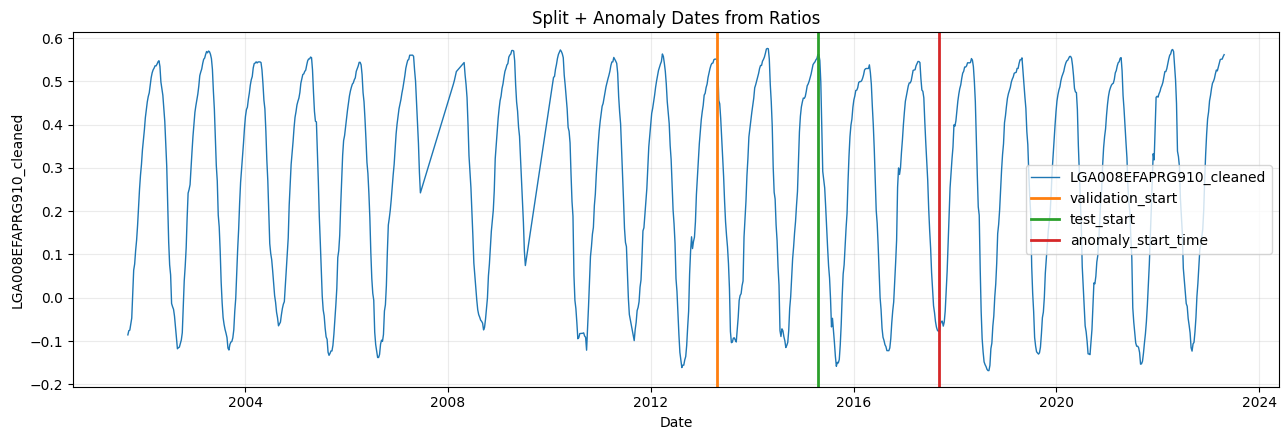

In [21]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(series.index, series.values, color="tab:blue", linewidth=1.0, label=value_column)
ax.axvline(validation_start, color="tab:orange", linewidth=2, label="validation_start")
ax.axvline(test_start, color="tab:green", linewidth=2, label="test_start")
ax.axvline(anomaly_start_time, color="tab:red", linewidth=2, label="anomaly_start_time")
ax.set_title("Split + Anomaly Dates from Ratios")
ax.set_xlabel("Date")
ax.set_ylabel(value_column)
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()